In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
store = pd.read_csv("store.csv")


C:\Users\HARPAL\AppData\Local\Temp\ipykernel_13876\3053726640.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("train.csv")


In [3]:
print(train.shape)
print(test.shape)
print(store.shape)

(1017209, 9)
(41088, 8)
(1115, 10)


In [4]:
train = train.merge(store, on='Store', how='left')
test = test.merge(store, on='Store', how='left')

print(train.head())

   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
0              1         c          a               1270.0   
1              1         a          a                570.0   
2              1         a          a              14130.0   
3              1         c          c                620.0   
4              1         a          a              29910.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
0                        9.0                    2008.0       0   
1                   

In [5]:
import logging
import pickle
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

import mlflow
import mlflow.sklearn

In [6]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.


In [10]:
logging.basicConfig(
    filename='rossmann_project.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logging.info("Project Started")


In [9]:
print(train.isnull().sum())

train.fillna(0, inplace=True)
test.fillna(0, inplace=True)

logging.info("Missing values handled")


Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64


In [12]:
train = train.merge(store, on='Store', how='left')
test = test.merge(store, on='Store', how='left')

print(train.head())

   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday StoreType_x  ...  PromoInterval_y  StoreType  Assortment  \
0              1           c  ...              NaN          c           a   
1              1           a  ...  Jan,Apr,Jul,Oct          a           a   
2              1           a  ...  Jan,Apr,Jul,Oct          a           a   
3              1           c  ...              NaN          c           c   
4              1           a  ...              NaN          a           a   

   CompetitionDistance  CompetitionOpenSinceMonth  Competition

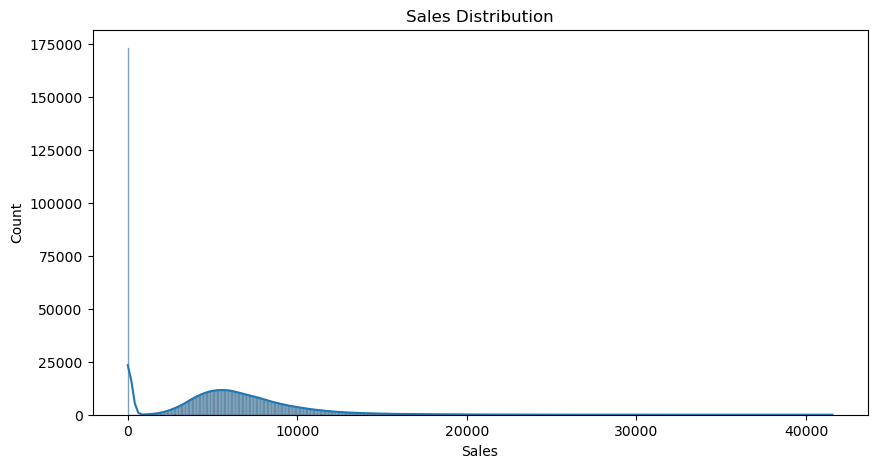

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(train['Sales'], kde=True)
plt.title("Sales Distribution")
plt.show()

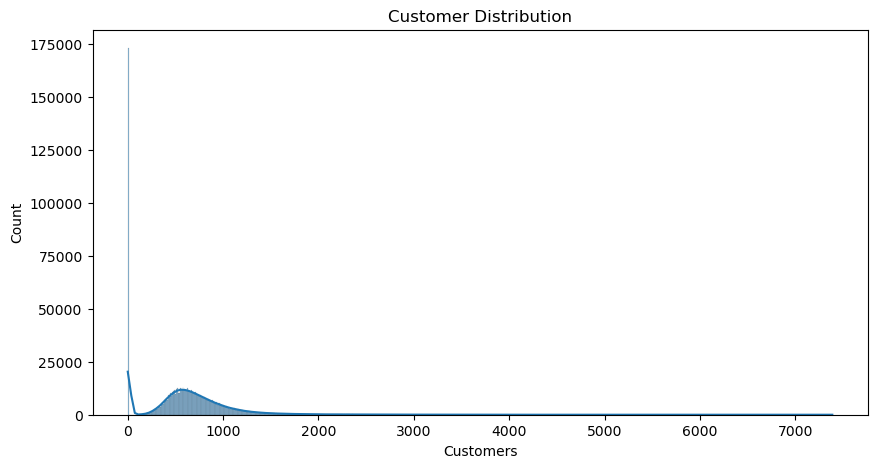

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(train['Customers'], kde=True)
plt.title("Customer Distribution")
plt.show()

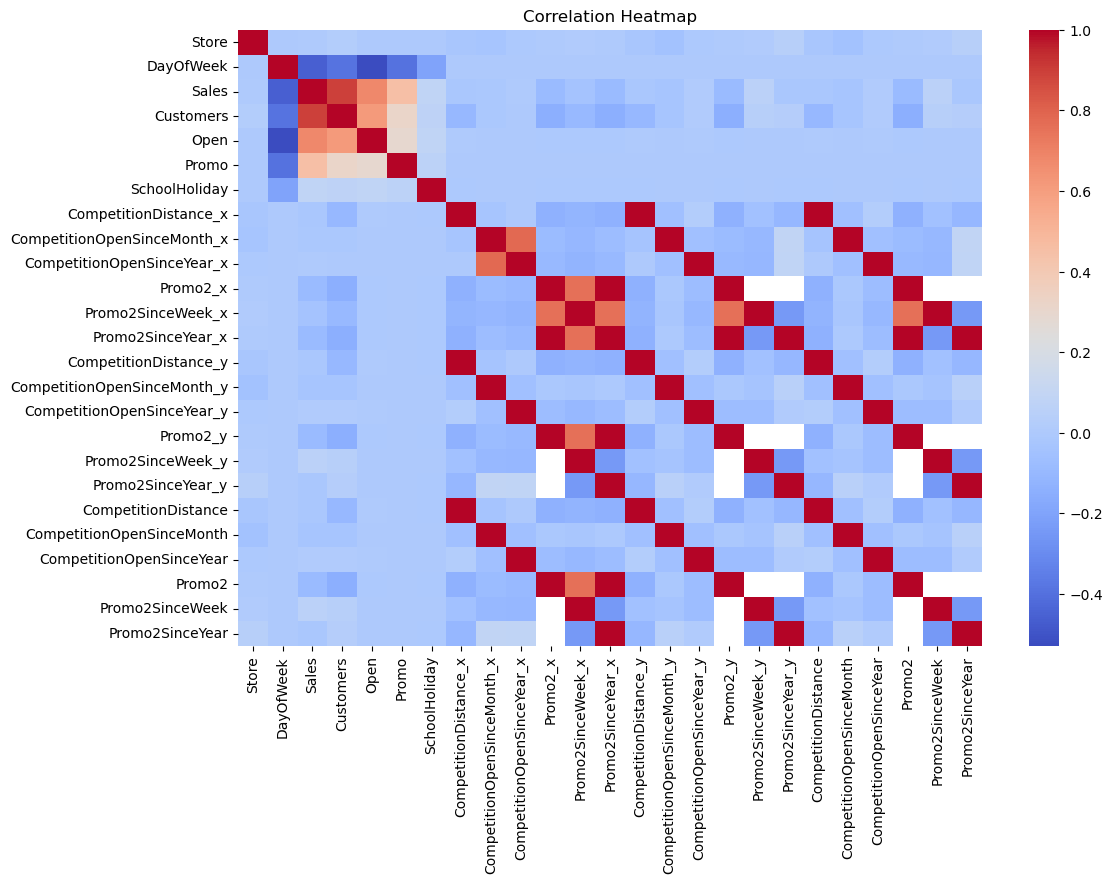

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(train.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

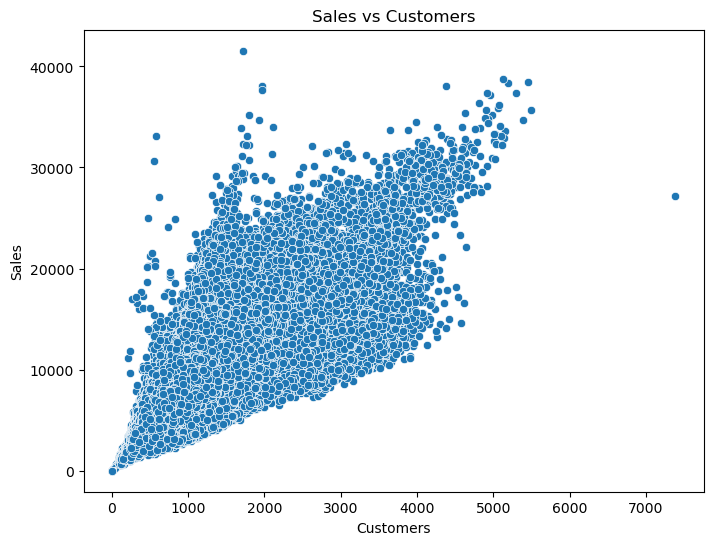

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Customers', y='Sales', data=train)
plt.title("Sales vs Customers")
plt.show()

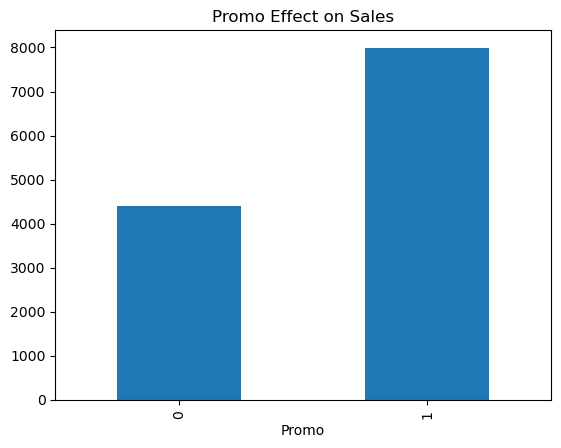

In [17]:
promo_sales = train.groupby('Promo')['Sales'].mean()

promo_sales.plot(kind='bar')
plt.title("Promo Effect on Sales")
plt.show()

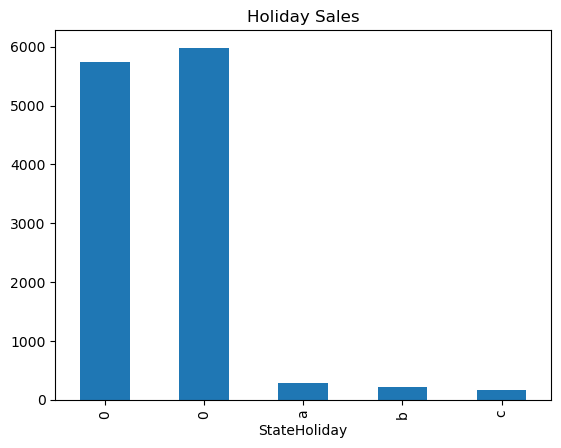

In [18]:
holiday_sales = train.groupby('StateHoliday')['Sales'].mean()

holiday_sales.plot(kind='bar')
plt.title("Holiday Sales")
plt.show()

logging.info("EDA Completed")

In [19]:
def feature_engineering(df):

    df['Date'] = pd.to_datetime(df['Date'])

    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week

    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['Weekend'] = df['DayOfWeek'].isin([5,6]).astype(int)

    df['BeginningMonth'] = (df['Day'] <= 10).astype(int)
    df['MidMonth'] = ((df['Day'] > 10) & (df['Day'] <=20)).astype(int)
    df['EndMonth'] = (df['Day'] > 20).astype(int)

    return df

train = feature_engineering(train)
test = feature_engineering(test)

logging.info("Feature Engineering Done")

In [20]:
categorical_cols = [
    'StoreType_x',
    'Assortment_y',
    'StateHoliday',
    'PromoInterval_x'
]

for col in categorical_cols:

    train[col] = train[col].astype(str)
    test[col] = test[col].astype(str)

    le = LabelEncoder()

    combined = pd.concat([
        train[col],
        test[col]
    ])

    le.fit(combined)

    train[col] = le.transform(train[col])
    test[col] = le.transform(test[col])

print("Encoding Complete")

Encoding Complete


In [21]:
X = train.drop(
    columns=['Sales', 'Date'],
    errors='ignore'
)

y = train['Sales']

In [22]:
X_test = test.drop(
    columns=['Date'],
    errors='ignore'
)

In [23]:
if 'Customers' in X.columns:
    X.drop(columns=['Customers'], inplace=True)

In [24]:
if 'Id' in X_test.columns:
    X_test.drop(columns=['Id'], inplace=True)

In [25]:
missing_cols = set(X.columns) - set(X_test.columns)

for col in missing_cols:
    X_test[col] = 0

extra_cols = set(X_test.columns) - set(X.columns)

for col in extra_cols:
    X_test.drop(columns=[col], inplace=True)

In [26]:
X_test = X_test[X.columns]

print("Train Shape:", X.shape)
print("Test Shape:", X_test.shape)

Train Shape: (1017209, 41)
Test Shape: (41088, 41)


In [27]:
object_cols = X.select_dtypes(
    include=['object']
).columns

print("Remaining object columns:")
print(object_cols)

Remaining object columns:
Index(['Assortment_x', 'StoreType_y', 'PromoInterval_y', 'StoreType',
       'Assortment', 'PromoInterval'],
      dtype='object')


In [28]:
for col in object_cols:

    X[col] = LabelEncoder().fit_transform(
        X[col].astype(str)
    )

    if col in X_test.columns:
        X_test[col] = LabelEncoder().fit_transform(
            X_test[col].astype(str)
        )

In [29]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)


X_train, X_valid, y_train, y_valid = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Preprocessing Done")

Preprocessing Done


In [32]:
mae = mean_absolute_error(y_valid, pred)
rmse = np.sqrt(mean_squared_error(y_valid, pred))
r2 = r2_score(y_valid, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

logging.info("Model Training Completed")

MAE: 478.98078489200856
RMSE: 821.5766637947727
R2: 0.9543581366160104


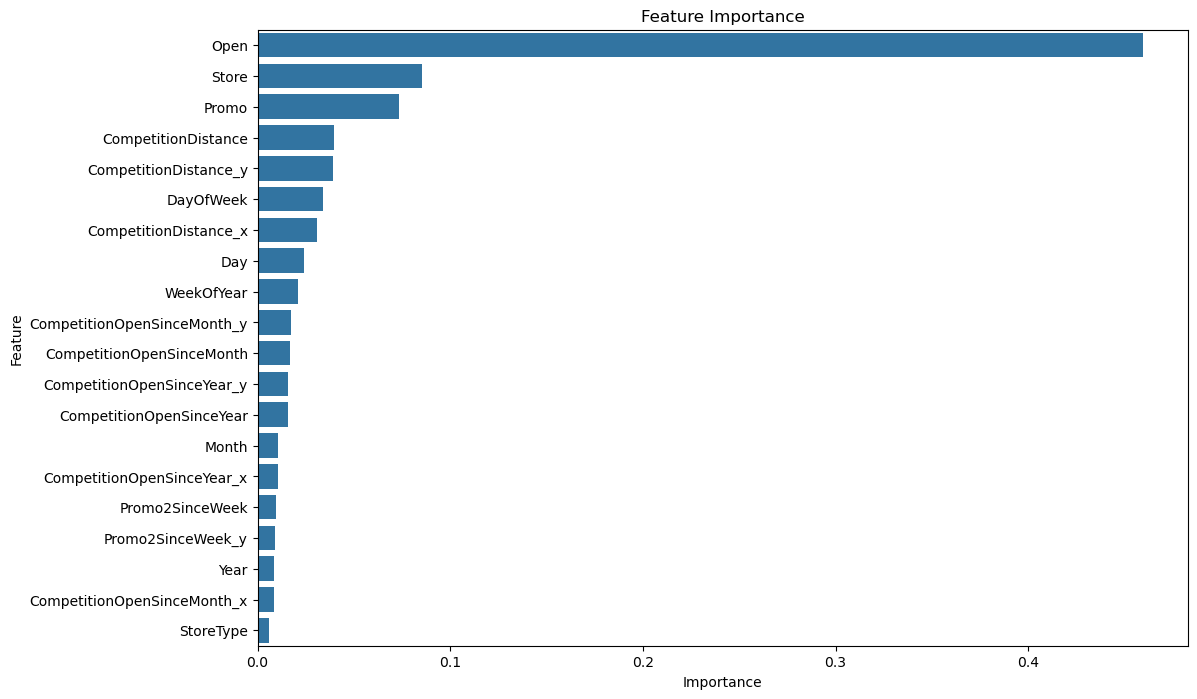

In [33]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(12,8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(20)
)
plt.title("Feature Importance")
plt.show()


In [34]:
timestamp = datetime.now().strftime("%d-%m-%Y-%H-%M-%S")

filename = f"{timestamp}.pkl"

pickle.dump(model, open(filename, 'wb'))

print("Model Saved:", filename)

logging.info("Model Saved")

Model Saved: 23-06-2026-21-38-46.pkl


In [43]:
mlflow.set_experiment("Rossmann Sales Forecast")

with mlflow.start_run():

    mlflow.log_param("n_estimators",100)
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2", r2)

    mlflow.sklearn.log_model(
    sk_model=model,
    artifact_path="RandomForestModel",
    serialization_format="cloudpickle"
    )

logging.info("MLflow Tracking Done")

2026/06/23 22:13:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/23 22:13:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/23 22:14:28 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\HARPAL\AppData\Local\Temp\tmp7vvptrio\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.6.1', 'cloudpickle==3.0.0']. Set logging level to DEBUG to see the full traceback. 


OSError: [WinError 112] There is not enough space on the disk

In [42]:
import shutil

total, used, free = shutil.disk_usage("C:\\")

print("Free GB:", round(free / (1024**3), 2))

Free GB: 8.56


In [45]:
sales_series = train[['Date','Sales']]

sales_series = sales_series.groupby(
    'Date'
)['Sales'].sum()

sales_series = sales_series.values

In [46]:


scaler_lstm = StandardScaler()

scaled_data = scaler_lstm.fit_transform(
    sales_series.reshape(-1,1)
)

In [48]:
X_lstm = []
y_lstm = []

window = 10

for i in range(window, len(scaled_data)):

    X_lstm.append(
        scaled_data[i-window:i,0]
    )

    y_lstm.append(
        scaled_data[i,0]
    )

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

X_lstm = X_lstm.reshape(
    X_lstm.shape[0],
    X_lstm.shape[1],
    1
)

In [49]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_lstm.shape[1],
            1
        )
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(32))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

history = lstm_model.fit(
    X_lstm,
    y_lstm,
    epochs=10,
    batch_size=32
)

logging.info("LSTM Model Completed")

C:\Users\HARPAL\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.9841
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.9727
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9719
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9609
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9533
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9220
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.8372
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7351
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6363
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.5421


In [50]:
result = adfuller(sales_series)

print("ADF Statistic:", result[0])
print("P-value:", result[1])

ADF Statistic: -4.7616145245956165
P-value: 6.436731330559263e-05


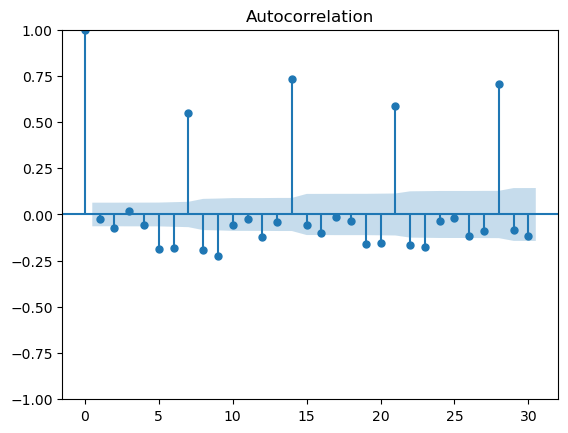

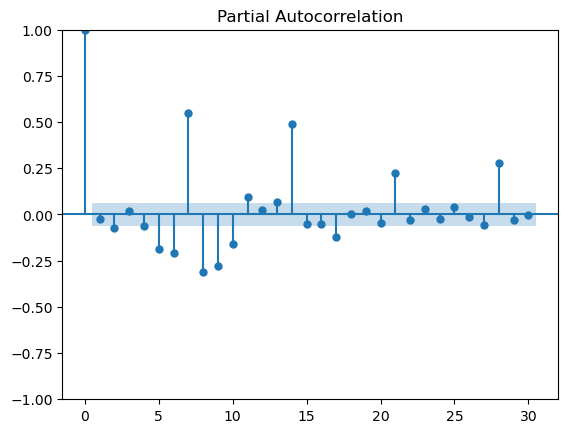

In [51]:
plot_acf(sales_series)
plt.show()

plot_pacf(sales_series)
plt.show()